<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSTM

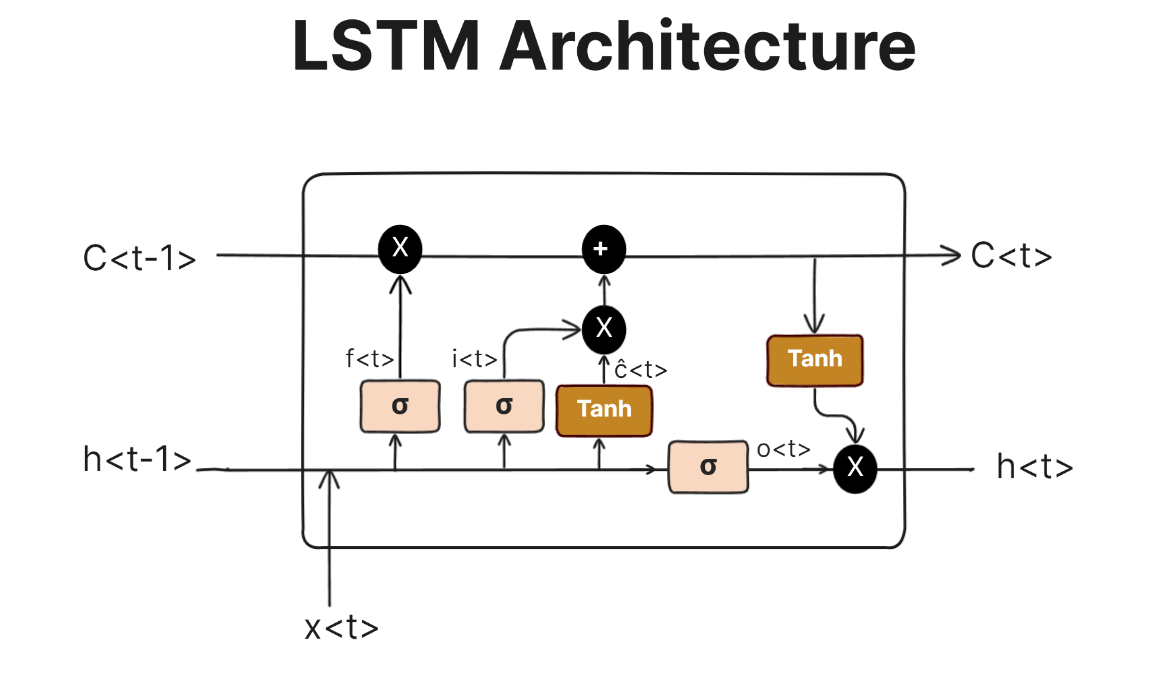

Install NLTK

In [1]:
!pip install nltk

What is NLTK?

NLTK stands for Natural Language Toolkit.

It is a powerful Python library used for natural language processing (NLP) tasks.



What Can NLTK Do?

NLTK provides tools to help computers understand, interpret, and manipulate human language.

Some key features:

- `Tokenization`: Breaking text into words or sentences
- `Stopword removal`: 	Removing common words like "the", "is", "in"
- `Stemming`:	Reducing words to their root form (e.g., “running” → “run”)
- `Lemmatization`:	Like stemming, but more accurate (e.g., “better” → “good”)
- `POS tagging`: Part-of-speech tagging (e.g., "run" = verb or noun?)
- `Text Classification`:	Sentiment analysis, spam detection, etc.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize
import nltk

In [3]:
document = """
Muhammad Ali Jinnah born Mahomedali Jinnahbhai 25 December 1876 11 September 1948 was a barrister, statesman, and the founder of Pakistan.
Jinnah served as the leader of the All-India Muslim League from 1913 until the inception of Pakistan on 14 August 1947, and then as Pakistan's first governor-general until his death a year later in 1948.
Born at Wazir Mansion in Karachi, Jinnah was trained as a barrister at Lincoln's Inn in London, England.
Upon his return to India, he enrolled at the Bombay High Court, and took an interest in national politics, which eventually replaced his legal practice.
Jinnah rose to prominence in the Indian National Congress in the first two decades of the 20th century.
In these early years of his political career, Jinnah advocated for Hindu–Muslim unity, helping to shape the 1916 Lucknow Pact between the Congress and the All-India Muslim League, in which Jinnah had also become prominent.
Jinnah became a key leader in the All-India Home Rule League, and proposed a fourteen-point constitutional reform plan to safeguard the political rights of Muslims in the Indian subcontinent.
In 1920, however, Jinnah resigned from the Congress when it agreed to follow a campaign of satyagraha, which he regarded as political anarchy.
After joining the All-India Muslim League, Jinnah worked for the rights of Muslims in the subcontinent to protect them from the threat of marginalisation in a Hindu-dominated state.
In 1940, the Muslim League, led by Jinnah, passed the Lahore Resolution. During the Second World War, the League gained strength while leaders of the Congress were imprisoned, and in the provincial elections held shortly after the war, it won most of the seats reserved for Muslims.
Ultimately, the Congress and the Muslim League could not reach a power-sharing formula that would allow the entirety of British India to be united as a single state following independence, leading all parties to agree instead to the independence of a Hindu-majority India, and for a predominantly Muslim state of Pakistan.
As the first governor-general of Pakistan, Jinnah worked to establish the government of the new nation and policies to aid the millions of Muslim migrants who had emigrated from regions that became part of the Dominion of India to Pakistan after the independence of both states, personally supervising the establishment of refugee camps.
Jinnah died at age 71 in September 1948, just over a year after Pakistan gained independence from the United Kingdom. He left a deep and respected legacy in Pakistan.
Several universities and public buildings in Pakistan bear Jinnah's name. He is revered in Pakistan as the Quaid-e-Azam ("Great Leader") and Baba-e-Qaum ("Father of the Nation").
His birthday is also observed as a national holiday in the country. According to his biographer, Stanley Wolpert, Jinnah remains Pakistan's greatest leader.
"""

In [4]:
# Tokenization

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
# tokenize
tokens = word_tokenize(document.lower())

In [ ]:
tokens

['muhammad',
 'ali',
 'jinnah',
 'born',
 'mahomedali',
 'jinnahbhai',
 '25',
 'december',
 '1876',
 '11',
 'september',
 '1948',
 'was',
 'a',
 'barrister',
 ',',
 'statesman',
 ',',
 'and',
 'the',
 'founder',
 'of',
 'pakistan',
 '.',
 'jinnah',
 'served',
 'as',
 'the',
 'leader',
 'of',
 'the',
 'all-india',
 'muslim',
 'league',
 'from',
 '1913',
 'until',
 'the',
 'inception',
 'of',
 'pakistan',
 'on',
 '14',
 'august',
 '1947',
 ',',
 'and',
 'then',
 'as',
 'pakistan',
 "'s",
 'first',
 'governor-general',
 'until',
 'his',
 'death',
 'a',
 'year',
 'later',
 'in',
 '1948.',
 'born',
 'at',
 'wazir',
 'mansion',
 'in',
 'karachi',
 ',',
 'jinnah',
 'was',
 'trained',
 'as',
 'a',
 'barrister',
 'at',
 'lincoln',
 "'s",
 'inn',
 'in',
 'london',
 ',',
 'england',
 '.',
 'upon',
 'his',
 'return',
 'to',
 'india',
 ',',
 'he',
 'enrolled',
 'at',
 'the',
 'bombay',
 'high',
 'court',
 ',',
 'and',
 'took',
 'an',
 'interest',
 'in',
 'national',
 'politics',
 ',',
 'which',
 'e

In [7]:
# build vocab
vocab = {'<unk>':0}

for token in Counter(tokens).keys():
  if token not in vocab:
    vocab[token] = len(vocab)

vocab

{'<unk>': 0,
 'muhammad': 1,
 'ali': 2,
 'jinnah': 3,
 'born': 4,
 'mahomedali': 5,
 'jinnahbhai': 6,
 '25': 7,
 'december': 8,
 '1876': 9,
 '11': 10,
 'september': 11,
 '1948': 12,
 'was': 13,
 'a': 14,
 'barrister': 15,
 ',': 16,
 'statesman': 17,
 'and': 18,
 'the': 19,
 'founder': 20,
 'of': 21,
 'pakistan': 22,
 '.': 23,
 'served': 24,
 'as': 25,
 'leader': 26,
 'all-india': 27,
 'muslim': 28,
 'league': 29,
 'from': 30,
 '1913': 31,
 'until': 32,
 'inception': 33,
 'on': 34,
 '14': 35,
 'august': 36,
 '1947': 37,
 'then': 38,
 "'s": 39,
 'first': 40,
 'governor-general': 41,
 'his': 42,
 'death': 43,
 'year': 44,
 'later': 45,
 'in': 46,
 '1948.': 47,
 'at': 48,
 'wazir': 49,
 'mansion': 50,
 'karachi': 51,
 'trained': 52,
 'lincoln': 53,
 'inn': 54,
 'london': 55,
 'england': 56,
 'upon': 57,
 'return': 58,
 'to': 59,
 'india': 60,
 'he': 61,
 'enrolled': 62,
 'bombay': 63,
 'high': 64,
 'court': 65,
 'took': 66,
 'an': 67,
 'interest': 68,
 'national': 69,
 'politics': 70,
 'wh

In [8]:
len(vocab)

239

In [9]:
input_sentences = document.split('\n')
len(input_sentences)

17

In [10]:
input_sentences

['',
 'Muhammad Ali Jinnah born Mahomedali Jinnahbhai 25 December 1876 11 September 1948 was a barrister, statesman, and the founder of Pakistan. ',
 "Jinnah served as the leader of the All-India Muslim League from 1913 until the inception of Pakistan on 14 August 1947, and then as Pakistan's first governor-general until his death a year later in 1948.",
 "Born at Wazir Mansion in Karachi, Jinnah was trained as a barrister at Lincoln's Inn in London, England. ",
 'Upon his return to India, he enrolled at the Bombay High Court, and took an interest in national politics, which eventually replaced his legal practice. ',
 'Jinnah rose to prominence in the Indian National Congress in the first two decades of the 20th century.',
 'In these early years of his political career, Jinnah advocated for Hindu–Muslim unity, helping to shape the 1916 Lucknow Pact between the Congress and the All-India Muslim League, in which Jinnah had also become prominent. ',
 'Jinnah became a key leader in the All

text -> numerical indices

In [11]:
def text_to_indices(sentence, vocab):

  numerical_sentence = []

  for token in sentence:
    if token in vocab:
      numerical_sentence.append(vocab[token])
    else:
      numerical_sentence.append(vocab['<unk>'])

  return numerical_sentence


In [12]:
input_numerical_sentences = []

for sentence in input_sentences:
  input_numerical_sentences.append(text_to_indices(word_tokenize(sentence.lower()), vocab))


In [13]:
len(input_numerical_sentences)

17

In [14]:
input_numerical_sentences

[[],
 [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  16,
  18,
  19,
  20,
  21,
  22,
  23],
 [3,
  24,
  25,
  19,
  26,
  21,
  19,
  27,
  28,
  29,
  30,
  31,
  32,
  19,
  33,
  21,
  22,
  34,
  35,
  36,
  37,
  16,
  18,
  38,
  25,
  22,
  39,
  40,
  41,
  32,
  42,
  43,
  14,
  44,
  45,
  46,
  12,
  23],
 [4,
  48,
  49,
  50,
  46,
  51,
  16,
  3,
  13,
  52,
  25,
  14,
  15,
  48,
  53,
  39,
  54,
  46,
  55,
  16,
  56,
  23],
 [57,
  42,
  58,
  59,
  60,
  16,
  61,
  62,
  48,
  19,
  63,
  64,
  65,
  16,
  18,
  66,
  67,
  68,
  46,
  69,
  70,
  16,
  71,
  72,
  73,
  42,
  74,
  75,
  23],
 [3, 76, 59, 77, 46, 19, 78, 69, 79, 46, 19, 40, 80, 81, 21, 19, 82, 83, 23],
 [46,
  84,
  85,
  86,
  21,
  42,
  87,
  88,
  16,
  3,
  89,
  90,
  91,
  92,
  16,
  93,
  59,
  94,
  19,
  95,
  96,
  97,
  98,
  19,
  79,
  18,
  19,
  27,
  28,
  29,
  16,
  46,
  71,
  3,
  99,
  100,
  101,
  102,
  23],
 [3,
  103,

Create training sequence

In [15]:
training_sequence = []
for sentence in input_numerical_sentences:

  for i in range(1, len(sentence)):
    training_sequence.append(sentence[:i+1])

In [16]:
len(training_sequence)

507

Check First Five Training Sequence

In [17]:
training_sequence[:5]

[[1, 2], [1, 2, 3], [1, 2, 3, 4], [1, 2, 3, 4, 5], [1, 2, 3, 4, 5, 6]]

Fint out the Maximum Length of sequence

In [18]:
len_list = []

for sequence in training_sequence:
  len_list.append(len(sequence))

max(len_list)

56

Check the First Sequence Length

In [19]:
training_sequence[0]

[1, 2]

- Maximum Sequence Length => 62
- But First Srquence Length => 2

Now, We have to make the sequence length equal in order to feed them to networt. To solve this issue, we have to use `Padding`

**What is Padding?**

Padding means adding extra values (usually zeros) to a sequence to make all sequences in a batch the same length.

Why?
- Neural networks (especially RNNs, LSTMs) expect inputs of the same length across batches. Since sentences or sequences usually vary in length, we "pad" shorter ones to match the longest sequence.

Types:

- `Pre-padding` means adding padding values at the beginning of the sequence.

 Example: Suppose `max length = 5`, and your original sequence is: `[4, 5, 6]`

 After pre-padding `(with 0)`: `[0, 0, 4, 5, 6]`

- `Post-padding` means adding padding values at the end of the sequence.

 Example:  Original sequence: `[4, 5, 6]`

 After post-padding `(with 0)`: `[4, 5, 6, 0, 0]`



In [20]:
padded_training_sequence = []
for sequence in training_sequence:

  padded_training_sequence.append([0]*(max(len_list) - len(sequence)) + sequence)

In [21]:
len(padded_training_sequence[3])

56

In [22]:
padded_training_sequence = torch.tensor(padded_training_sequence, dtype=torch.long)

In [23]:
padded_training_sequence

tensor([[  0,   0,   0,  ...,   0,   1,   2],
        [  0,   0,   0,  ...,   1,   2,   3],
        [  0,   0,   0,  ...,   2,   3,   4],
        ...,
        [  0,   0,   0,  ...,  22,  39, 238],
        [  0,   0,   0,  ...,  39, 238,  26],
        [  0,   0,   0,  ..., 238,  26,  23]])

Now, split the `padded sequence` into `input` & `output`. Such that:
- input : extract the `all` values from the padded sequence except `last one`
- output : extract the `last one value`

In [24]:
X = padded_training_sequence[:, :-1]
y = padded_training_sequence[:,-1]

In [25]:
X

tensor([[  0,   0,   0,  ...,   0,   0,   1],
        [  0,   0,   0,  ...,   0,   1,   2],
        [  0,   0,   0,  ...,   1,   2,   3],
        ...,
        [  0,   0,   0,  ..., 237,  22,  39],
        [  0,   0,   0,  ...,  22,  39, 238],
        [  0,   0,   0,  ...,  39, 238,  26]])

In [26]:
y

tensor([  2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,
         16,  17,  16,  18,  19,  20,  21,  22,  23,  24,  25,  19,  26,  21,
         19,  27,  28,  29,  30,  31,  32,  19,  33,  21,  22,  34,  35,  36,
         37,  16,  18,  38,  25,  22,  39,  40,  41,  32,  42,  43,  14,  44,
         45,  46,  12,  23,  48,  49,  50,  46,  51,  16,   3,  13,  52,  25,
         14,  15,  48,  53,  39,  54,  46,  55,  16,  56,  23,  42,  58,  59,
         60,  16,  61,  62,  48,  19,  63,  64,  65,  16,  18,  66,  67,  68,
         46,  69,  70,  16,  71,  72,  73,  42,  74,  75,  23,  76,  59,  77,
         46,  19,  78,  69,  79,  46,  19,  40,  80,  81,  21,  19,  82,  83,
         23,  84,  85,  86,  21,  42,  87,  88,  16,   3,  89,  90,  91,  92,
         16,  93,  59,  94,  19,  95,  96,  97,  98,  19,  79,  18,  19,  27,
         28,  29,  16,  46,  71,   3,  99, 100, 101, 102,  23, 103,  14, 104,
         26,  46,  19,  27, 105, 106,  29,  16,  18, 107,  14, 1

Create Custom Dataset Class

In [27]:
class CustomDataset(Dataset):

  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return self.X.shape[0]

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

Instance of Custom Dataset Class

In [28]:
dataset = CustomDataset(X,y)

In [29]:
len(dataset)

507

In [30]:
dataset[2]

(tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 1, 2, 3]),
 tensor(4))

Now, create dataloader

In [31]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [32]:
# now check
for x, y in dataloader:
  print(x, y)

tensor([[  0,   0,   0,  ...,  44,  45,  46],
        [  0,   0,   0,  ...,  46,  19,  40],
        [  0,   0,   0,  ...,   3, 129,  90],
        ...,
        [  0,   0,   0,  ...,  18, 107,  14],
        [  0,   0,   0,  ..., 190, 191,  99],
        [  0,   0,   0,  ..., 144, 145,  16]]) tensor([ 12,  80,  19,  16, 175, 219, 114,  68,  93,  30,  85, 159,  28,  18,
         22,  87, 169,  56,  36,  19,  19,  14,  22,  16, 223,  12, 118, 226,
         19, 108, 192,  19])
tensor([[  0,   0,   0,  ...,  16,   3, 129],
        [  0,   0,   0,  ...,  59,  94,  19],
        [  0,   0,   0,  ...,  32,  19,  33],
        ...,
        [  0,   0,   0,  ...,  65,  16,  18],
        [  0,   0,   0,  ..., 174, 175,  16],
        [  0,   0,   0,  ...,  59, 122,  14]]) tensor([ 90,  95,  21,  69,  16,  16, 133,  59,  42, 109,  59,  19,  89,  19,
        181, 139, 227,  59,  15,  84, 111,  18,  19,  16, 201,  14,  71,  48,
         14,  66, 176, 123])
tensor([[  0,   0,   0,  ...,  28, 190, 191],
    

Custom LSTM Model

In [33]:
class LSTMModel(nn.Module):

  def __init__(self, vocab_size):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, 100)
    self.lstm = nn.LSTM(100, 150, batch_first=True)
    self.fc = nn.Linear(150, vocab_size)

  def forward(self, x):
    embedded = self.embedding(x)
    intermediate_hidden_states, (final_hidden_state, final_cell_state) = self.lstm(embedded)
    output = self.fc(final_hidden_state.squeeze(0))
    return output

# Example Scalable network
import torch
import torch.nn as nn
class LSTMModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=100,
        hidden_size=150,
        num_layers=1,
        dropout=0.0,
        bidirectional=False
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        directions = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * directions, vocab_size)
    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        if self.bidirectional:
            # concatenate forward and backward hidden states
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            # last layer hidden state
            hidden = hidden[-1]
        output = self.fc(hidden)
        return output

Intance of Custom LSTM Model

In [34]:
model = LSTMModel(len(vocab))

In [35]:
for name, param in model.named_parameters():
    print(name, param.numel())

embedding.weight 23900
lstm.weight_ih_l0 60000
lstm.weight_hh_l0 90000
lstm.bias_ih_l0 600
lstm.bias_hh_l0 600
fc.weight 35850
fc.bias 239


check the cuda availability

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

move the model to cuda

In [37]:
model.to(device)

LSTMModel(
  (embedding): Embedding(239, 100)
  (lstm): LSTM(100, 150, batch_first=True)
  (fc): Linear(in_features=150, out_features=239, bias=True)
)

In [38]:
# Hyperparameters

epochs = 50
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [39]:
# training loop

for epoch in range(epochs):
  total_loss = 0

  for batch_x, batch_y in dataloader:

    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    optimizer.zero_grad()

    output = model(batch_x)

    loss = criterion(output, batch_y)

    loss.backward()

    optimizer.step()

    total_loss = total_loss + loss.item()

  print(f"Epoch: {epoch + 1}, Loss: {total_loss:.4f}")

Epoch: 1, Loss: 87.3218
Epoch: 2, Loss: 82.4156
Epoch: 3, Loss: 75.3141
Epoch: 4, Loss: 69.9369
Epoch: 5, Loss: 65.3940
Epoch: 6, Loss: 60.9161
Epoch: 7, Loss: 56.1704
Epoch: 8, Loss: 51.5319
Epoch: 9, Loss: 47.1785
Epoch: 10, Loss: 42.8157
Epoch: 11, Loss: 38.7339
Epoch: 12, Loss: 34.8867
Epoch: 13, Loss: 31.1877
Epoch: 14, Loss: 27.8265
Epoch: 15, Loss: 24.6984
Epoch: 16, Loss: 21.6871
Epoch: 17, Loss: 19.1157
Epoch: 18, Loss: 16.7458
Epoch: 19, Loss: 14.7202
Epoch: 20, Loss: 12.9905
Epoch: 21, Loss: 11.4362
Epoch: 22, Loss: 10.0999
Epoch: 23, Loss: 8.9410
Epoch: 24, Loss: 7.9598
Epoch: 25, Loss: 7.1082
Epoch: 26, Loss: 6.4035
Epoch: 27, Loss: 5.7755
Epoch: 28, Loss: 5.2584
Epoch: 29, Loss: 4.8054
Epoch: 30, Loss: 4.3985
Epoch: 31, Loss: 4.0456
Epoch: 32, Loss: 3.7388
Epoch: 33, Loss: 3.4903
Epoch: 34, Loss: 3.2428
Epoch: 35, Loss: 3.0089
Epoch: 36, Loss: 2.8283
Epoch: 37, Loss: 2.6717
Epoch: 38, Loss: 2.5147
Epoch: 39, Loss: 2.3632
Epoch: 40, Loss: 2.2562
Epoch: 41, Loss: 2.1277
Epo

In [40]:
output.shape

torch.Size([27, 239])

In [41]:
# prediction

def prediction(model, vocab, text):

  # tokenize
  tokenized_text = word_tokenize(text.lower())

  # text -> numerical indices
  numerical_text = text_to_indices(tokenized_text, vocab)

  # padding
  padded_text = torch.tensor([0] * (61 - len(numerical_text)) + numerical_text, dtype=torch.long).unsqueeze(0)

  # send to model
  output = model(padded_text)

  # convert logit to probs
  probs = torch.nn.functional.softmax(output, dim=1)

  # predicted index
  value, index = torch.max(probs, dim=1)

  # merge with text
  return text + " " + list(vocab.keys())[index]

In [42]:
prediction(model, vocab, "The Quaid was born at")

'The Quaid was born at wazir'

In [43]:
import time

num_tokens = 10
input_text = "Muhammad Ali Jinnah born"

for i in range(num_tokens):
  output_text = prediction(model, vocab, input_text)
  print(output_text)
  input_text = output_text
  time.sleep(0.5)


Muhammad Ali Jinnah born mahomedali
Muhammad Ali Jinnah born mahomedali jinnahbhai
Muhammad Ali Jinnah born mahomedali jinnahbhai 25
Muhammad Ali Jinnah born mahomedali jinnahbhai 25 december
Muhammad Ali Jinnah born mahomedali jinnahbhai 25 december 1876
Muhammad Ali Jinnah born mahomedali jinnahbhai 25 december 1876 11
Muhammad Ali Jinnah born mahomedali jinnahbhai 25 december 1876 11 september
Muhammad Ali Jinnah born mahomedali jinnahbhai 25 december 1876 11 september 1948
Muhammad Ali Jinnah born mahomedali jinnahbhai 25 december 1876 11 september 1948 was
Muhammad Ali Jinnah born mahomedali jinnahbhai 25 december 1876 11 september 1948 was a


In [44]:
dataloader1 = DataLoader(dataset, batch_size=32, shuffle=False)

In [45]:
# Function to calculate accuracy
def calculate_accuracy(model, dataloader, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # No need to compute gradients
        for batch_x, batch_y in dataloader1:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            # Get model predictions
            outputs = model(batch_x)

            # convert logit to probs
            probs = torch.nn.functional.softmax(outputs, dim=1)

            # Get the predicted word indices
            _, predicted = torch.max(probs, dim=1)

            # Compare with actual labels
            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    accuracy = (correct / total) * 100
    return accuracy

# Compute accuracy
accuracy = calculate_accuracy(model, dataloader, device)
print(f"Model Accuracy: {accuracy:.2f}%")


Model Accuracy: 99.01%
